# Notebook 2 — Fine-Tuning + HuggingFace Push
**CISC 886 — Llama 3.2 3B Instruct + QLoRA on Ubuntu Dialogue Corpus**

⚠️ **Run Notebook 1 first** — this notebook requires `train_ready.csv`, `valid_ready.csv`, `test_ready.csv`

Start this notebook with a **FRESH kernel** (Kernel → Restart) so RAM is clean before loading the model.

---

| Cell | What it does |
|---|---|
| 1-2 | Install & imports |
| 3 | Load CSVs → HF Dataset |
| 4 | Load Llama 3.2 3B + QLoRA |
| 5 | Baseline evaluation (pre fine-tuning) |
| 6 | Train |
| 7 | Fine-tuned evaluation + comparison |
| 8 | Save LoRA adapter |
| 9 | Export to GGUF (for Ollama on EC2) |
| 10 | Push to HuggingFace Hub |

In [1]:
# Install dependencies
!pip install -U "unsloth[colab-new]" --quiet

In [2]:
# Imports and GPU check
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import time
import json


from datasets import Dataset
from unsloth import FastLanguageModel, is_bfloat16_supported
from trl import SFTTrainer
from transformers import TrainingArguments
from rouge_score import rouge_scorer
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score


warnings.filterwarnings('ignore')

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [3]:
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

In [4]:
# Load the prepared CSV files → HuggingFace Datasets

print('Loading prepared datasets...')

train_df = pd.read_csv('train_ready.csv', nrows=10000)
valid_df = pd.read_csv('valid_ready.csv', nrows=2000)
test_df  = pd.read_csv('test_ready.csv')

print(f'Train : {len(train_df):,} dialogues')
print(f'Valid : {len(valid_df):,} dialogues')
print(f'Test  : {len(test_df):,}  dialogues')

# Rename column to 'text' as required by SFTTrainer's dataset_text_field
train_df = train_df.rename(columns={'full_text': 'text'})
valid_df = valid_df.rename(columns={'full_text': 'text'})


# Convert to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[['text']], preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df[['text']], preserve_index=False)

print(f'\ntrain_dataset : {train_dataset}')
print(f'valid_dataset : {valid_dataset}')
print(f'\nSample (first 400 chars):')
print(train_dataset[0]['text'][:400])

Loading prepared datasets...
Train : 10,000 dialogues
Valid : 2,000 dialogues
Test  : 500  dialogues

train_dataset : Dataset({
    features: ['text'],
    num_rows: 10000
})
valid_dataset : Dataset({
    features: ['text'],
    num_rows: 2000
})

Sample (first 400 chars):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a knowledgeable Ubuntu and Linux technical support assistant. Given a conversation history, provide a clear, accurate, and helpful response that resolves the technical issue. Use correct Linux commands where relevant.<|eot_id|><|start_header_id|>user<|end_header_id|>

DUse alt+click to move it<|eot_id|><|start_header_id|>assistan


In [7]:
# Load Llama 3.2 3B Instruct with 4-bit QLoRA via Unsloth
# ── Model config ──────────────────────────────────────────────────────────────
MAX_SEQ_LENGTH = 2048   # covers ~95% of dialogues
DTYPE          = None   # auto: float16 on T4, bfloat16 on A100
LOAD_IN_4BIT   = True   # QLoRA 4-bit — required to fit 3B model on T4 16GB

# System prompt — needed for inference cells below
SYSTEM_PROMPT = (
    "You are a knowledgeable Ubuntu and Linux technical support assistant. "
    "Given a conversation history, provide a clear, accurate, and helpful response "
    "that resolves the technical issue. Use correct Linux commands where relevant."
)

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = 'unsloth/Llama-3.2-3B-Instruct',
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = DTYPE,
    load_in_4bit   = LOAD_IN_4BIT,
)
print(f'Model loaded: {model.num_parameters():,} parameters')

# ── Attach LoRA adapters ──────────────────────────────────────────────────────
model = FastLanguageModel.get_peft_model(
    model,
    r               = 16,          # LoRA rank
    lora_alpha      = 32,          # alpha/r = 2 → stable scaling
    target_modules  = [
        'q_proj', 'k_proj', 'v_proj', 'o_proj',    # attention
        'gate_proj', 'up_proj', 'down_proj'         # MLP
    ],
    lora_dropout               = 0,         # 0 is optimal for QLoRA
    bias                       = 'none',
    use_gradient_checkpointing = 'unsloth', # saves VRAM during backprop
    use_rslora                 = True,      # rank-stabilised LoRA
    random_state               = 3407,
)
model.print_trainable_parameters()

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Model loaded: 3,212,749,824 parameters
trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511


In [8]:
# Baseline evaluation (BEFORE fine-tuning)
# Measure the base model so we can compare improvement after training.

FastLanguageModel.for_inference(model)

LINUX_KEYWORDS = [
    # Commands
    'sudo', 'apt', 'apt-get', 'grep', 'chmod', 'chown', 'ls', 'cd', 'mkdir',
    'rm', 'vim', 'nano', 'cat', 'tail', 'kill', 'systemctl', 'service',
    'pip', 'python', 'bash', 'echo', 'ssh', 'curl', 'wget', 'tar',
    'dpkg', 'find', 'git', 'docker', 'ifconfig', 'ping', 'mount',
    # UI / desktop actions
    'right click', 'click', 'menu', 'panel', 'terminal', 'properties',
    'settings', 'install', 'uninstall', 'restart', 'reboot', 'open',
    # Technical terms
    'package', 'driver', 'kernel', 'partition', 'filesystem', 'directory',
    'permission', 'port', 'network', 'wifi', 'dependency', 'repository',
    'config', 'file', 'folder', 'path', 'error', 'version', 'update',
    # Ubuntu specific
    'ubuntu', 'linux', 'gnome', 'unity', 'fstab', 'grub', 'root',
    'home', 'usr', 'etc', 'var', 'bin', '/dev', 'socket'
]


def generate_response(context_text: str, max_new_tokens: int = 150) -> str:
    """
    Generate response from full formatted context string.
    Context already contains system prompt + all previous turns.
    We just add the assistant generation prompt at the end.
    """
    # Add the assistant turn opener so model knows to generate the next response
    prompt = context_text + '<|start_header_id|>assistant<|end_header_id|>\n\n'
    
    inputs = tokenizer(
        prompt,
        return_tensors        = 'pt',
        return_attention_mask = True,
    ).to('cuda')

    with torch.no_grad():
        outputs = model.generate(
            inputs['input_ids'],
            attention_mask = inputs['attention_mask'],
            max_new_tokens = max_new_tokens,
            temperature    = 0.1,
            do_sample      = True,
            use_cache      = True,
            pad_token_id   = tokenizer.eos_token_id,
        )
    
    # Decode only the newly generated tokens (not the input)
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    response   = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return response.strip()

def is_relevant(text: str) -> int:
    return int(any(kw in text.lower() for kw in LINUX_KEYWORDS))

scorer_rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def parse_test_sample(full_text: str):
    try:
        parts     = full_text.split('<|start_header_id|>assistant<|end_header_id|>')
        reference = parts[-1].split('<|eot_id|>')[0].strip()
        context   = '<|start_header_id|>assistant<|end_header_id|>'.join(parts[:-1])

        # Remove ALL special tokens
        display = context
        for token in [
            '<|begin_of_text|>', '<|start_header_id|>', '<|end_header_id|>',
            '<|eot_id|>', 'system', 'user', 'assistant'
        ]:
            display = display.replace(token, ' ')

        # Remove the system prompt from display (too long)
        if 'technical support assistant' in display:
            display = display.split('relevant.')[- 1].strip()

        display = ' '.join(display.split())  # collapse whitespace
        return context.strip(), reference.strip(), display.strip()
    except Exception:
        return None, None, None

def run_evaluation(test_df, label, n=50):
    print(f'\nEvaluating [{label}] on {n} samples...')
    t0 = time.time()

    rouge_scores = []
    pred_labels  = []
    ref_labels   = []
    examples     = []

    col = 'full_text' if 'full_text' in test_df.columns else 'text'

    skipped = 0
    i_valid = 0

    for i in range(len(test_df)):
        if i_valid >= n:
            break

        context, reference, display_context = parse_test_sample(test_df[col].iloc[i])
        if context is None:
            skipped += 1
            continue

        # Skip very short or meaningless references
        if len(reference.split()) < 3:
            skipped += 1
            continue

        prediction = generate_response(context)

        rl = scorer_rouge.score(reference, prediction)['rougeL'].fmeasure
        rouge_scores.append(rl)
        pred_labels.append(is_relevant(prediction))
        ref_labels.append(is_relevant(reference))

        if len(examples) < 3:
            examples.append({
                'context'   : context[:250],
                'reference' : reference[:250],
                'prediction': prediction[:250],
            })

        i_valid += 1
        if i_valid % 10 == 0:
            elapsed = time.time() - t0
            print(f'  [{i_valid}/{n}]  ROUGE-L: {np.mean(rouge_scores):.3f}  '
                  f'({elapsed:.0f}s, ~{elapsed/i_valid*(n-i_valid):.0f}s left)')

    print(f'\n  Skipped {skipped} low-quality samples')
    print(f'  ROUGE-L F1     : {np.mean(rouge_scores):.3f}')
    print(f'  Relevance Rate : {np.mean(pred_labels)*100:.1f}%')
    print(f'  Time           : {time.time()-t0:.0f}s')

    # Classification report
    print(f'\n=== Classification Report — {label} ===')
    print(classification_report(
        ref_labels, pred_labels,
        target_names=['Not Relevant (0)', 'Technically Relevant (1)'],
        digits=3
    ))

    print(f'Accuracy  : {accuracy_score(ref_labels,  pred_labels):.3f}')
    print(f'Precision : {precision_score(ref_labels, pred_labels, zero_division=0):.3f}')
    print(f'Recall    : {recall_score(ref_labels,    pred_labels, zero_division=0):.3f}')
    print(f'F1 Score  : {f1_score(ref_labels,        pred_labels, zero_division=0):.3f}')

    return rouge_scores, pred_labels, ref_labels, examples

# Run with evaluation
ft_rouge, ft_preds, ft_refs, ft_examples = run_evaluation(
    test_df, 'Base Model', n=100
)


Evaluating [Base Model] on 100 samples...
  [10/100]  ROUGE-L: 0.074  (58s, ~525s left)
  [20/100]  ROUGE-L: 0.068  (125s, ~498s left)
  [30/100]  ROUGE-L: 0.068  (177s, ~413s left)
  [40/100]  ROUGE-L: 0.066  (238s, ~357s left)
  [50/100]  ROUGE-L: 0.064  (305s, ~305s left)
  [60/100]  ROUGE-L: 0.065  (364s, ~243s left)
  [70/100]  ROUGE-L: 0.062  (444s, ~190s left)
  [80/100]  ROUGE-L: 0.061  (519s, ~130s left)
  [90/100]  ROUGE-L: 0.061  (596s, ~66s left)
  [100/100]  ROUGE-L: 0.061  (669s, ~0s left)

  Skipped 16 low-quality samples
  ROUGE-L F1     : 0.061
  Relevance Rate : 99.0%
  Time           : 669s

=== Classification Report — Base Model ===
                          precision    recall  f1-score   support

        Not Relevant (0)      0.000     0.000     0.000        45
Technically Relevant (1)      0.545     0.982     0.701        55

                accuracy                          0.540       100
               macro avg      0.273     0.491     0.351       100
      

In [11]:
# Filter test_df to remove low quality references before sampling
def is_good_reference(text):
    if text is None:
        return False
    words = text.split()
    if len(words) < 5:              # too short
        return False
    if text.strip().endswith('?'):  # it's a question not an answer
        return False
    if 'http' in text.lower():      # just a URL
        return False
    if text.strip() in ['ok', 'okay', 'sure', 'yeah', 'lol', 'k']:
        return False
    return True

# Apply to test_df
good_indices = []
col = 'full_text' if 'full_text' in test_df.columns else 'text'

for i in range(len(test_df)):
    _, ref, _ = parse_test_sample(test_df[col].iloc[i])
    if ref and is_good_reference(ref):
        good_indices.append(i)

test_df_clean = test_df.iloc[good_indices].reset_index(drop=True)

In [12]:
samples = [
    {
        "context": "How do I check disk usage in Ubuntu?",
        "expected": 'Use the "du" command.'
    },
    {
        "context": "How do I list all running processes in Ubuntu?",
        "expected": 'use the "ps" command, or try top'
    },
    {
        "context": "How do I give a user sudo privileges?",
        "expected": "You need to create an entry for that user in /etc/sudoers."
    }
]

In [14]:
print("=== Sample Base Model Responses ===\n")

for i, sample in enumerate(samples):
    context_for_model = sample["context"]
    reference = sample["expected"]

    prediction = generate_response(context_for_model)

    print(f"--- Sample {i+1} ---")
    print(f"Input question     : {context_for_model}")
    print(f"Expected response  : {reference}")
    print(f"Model response     : {prediction}")
    print()

=== Sample Base Model Responses ===

--- Sample 1 ---
Input question     : How do I check disk usage in Ubuntu?
Expected response  : Use the "du" command.
Model response     : To check disk usage in Ubuntu, you can use the `df` command. Here are a few ways to do it:

**Method 1: Using the `df` command**

Open a terminal and type:
```
df -h
```
This will display a list of all mounted file systems, along with their usage percentage.

**Method 2: Using the `du` command**

You can also use the `du` command to estimate disk usage:
```
du -sh /
```
This will display the total size of the root file system.

**Method 3: Using the `lsblk` command**

If you want to see a more detailed view of disk usage, you can use the `lsblk` command:

--- Sample 2 ---
Input question     : How do I list all running processes in Ubuntu?
Expected response  : use the "ps" command, or try top
Model response     : You can list all running processes in Ubuntu using the following methods:

**Method 1: Using the `ps` 

In [15]:
# Fine-tuning

# ── Switch back to training mode ──────────────────────────────────────────────
fine_tuned_model = model
FastLanguageModel.for_training(fine_tuned_model)

trainer = SFTTrainer(
    model              = fine_tuned_model,
    tokenizer          = tokenizer,
    train_dataset      = train_dataset,
    eval_dataset       = valid_dataset,
    dataset_text_field = 'text',
    max_seq_length     = MAX_SEQ_LENGTH,
    dataset_num_proc   = 2,
    packing            = True,
    args = TrainingArguments(
        per_device_train_batch_size  = 2,
        gradient_accumulation_steps  = 4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),

        max_steps        = 1000,   # controls training length directly
        learning_rate     = 2e-4,  # slightly higher since fewer steps
        warmup_steps      = 50,                                  
        lr_scheduler_type = 'cosine',
        weight_decay      = 0.01,
        optim             = 'adamw_8bit',

        # ── Evaluate frequently to catch best checkpoint ──────────────────
        logging_steps          = 10,
        eval_strategy          = 'steps',
        eval_steps             = 100,   # evaluate every 100 steps
        save_strategy          = 'steps',
        save_steps             = 100,   # save every 100 steps
        load_best_model_at_end = True,  # auto picks best checkpoint
        metric_for_best_model  = 'eval_loss',

        output_dir = 'checkpoints',
    ),
)



Unsloth: Tokenizing ["text"] (num_proc=7):   0%|          | 0/10000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=7):   0%|          | 0/2000 [00:00<?, ? examples/s]

In [16]:
print('Starting training...')
trainer_stats = trainer.train()


print(f'\nTraining complete!')
print(f'  Runtime : {trainer_stats.metrics["train_runtime"]/60:.1f} min')
print(f'  Train loss (final) : {trainer_stats.metrics["train_loss"]:.4f}')

Starting training...
{'loss': '3.406', 'grad_norm': '4.081', 'learning_rate': '3.6e-05', 'epoch': '0.008'}
{'loss': '2.118', 'grad_norm': '2.34', 'learning_rate': '7.6e-05', 'epoch': '0.016'}
{'loss': '1.818', 'grad_norm': '1.766', 'learning_rate': '0.000116', 'epoch': '0.024'}
{'loss': '1.785', 'grad_norm': '1.739', 'learning_rate': '0.000156', 'epoch': '0.032'}
{'loss': '1.754', 'grad_norm': '1.624', 'learning_rate': '0.000196', 'epoch': '0.04'}
{'loss': '1.638', 'grad_norm': '1.451', 'learning_rate': '0.0002', 'epoch': '0.048'}
{'loss': '1.694', 'grad_norm': '1.413', 'learning_rate': '0.0001998', 'epoch': '0.056'}
{'loss': '1.62', 'grad_norm': '1.348', 'learning_rate': '0.0001995', 'epoch': '0.064'}
{'loss': '1.609', 'grad_norm': '1.367', 'learning_rate': '0.0001992', 'epoch': '0.072'}
{'loss': '1.663', 'grad_norm': '1.435', 'learning_rate': '0.0001987', 'epoch': '0.08'}
{'eval_loss': '1.8', 'eval_runtime': '191', 'eval_samples_per_second': '10.47', 'eval_steps_per_second': '5.236',

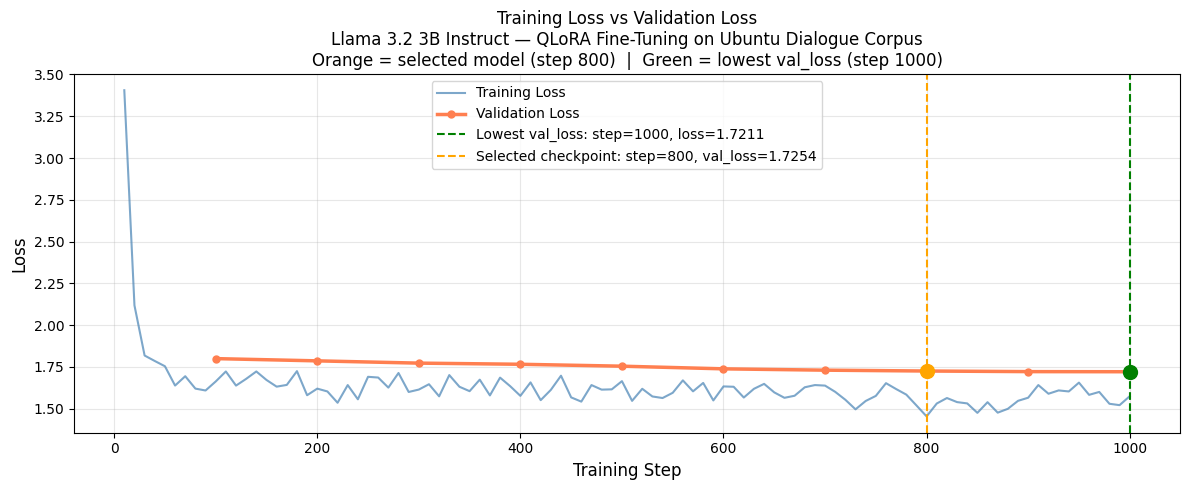

Lowest val_loss  : step 1000  val_loss=1.7211
Selected model   : step 800              val_loss=1.7254
Figure saved     : training_curve.png


In [17]:
# Load the trainer state from the checkpoints folder
STATE_PATH = 'checkpoints/checkpoint-1000/trainer_state.json'
with open(STATE_PATH, 'r') as f:
    state = json.load(f)

log_history  = state['log_history']
train_logs   = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs    = [x for x in log_history if 'eval_loss' in x]
train_steps  = [x['step'] for x in train_logs]
train_losses = [x['loss']      for x in train_logs]
eval_steps   = [x['step']      for x in eval_logs]
eval_losses  = [x['eval_loss'] for x in eval_logs]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_steps, train_losses,
        color='steelblue', linewidth=1.5, alpha=0.7, label='Training Loss')
ax.plot(eval_steps, eval_losses,
        color='coral', linewidth=2.5, marker='o', markersize=5,
        label='Validation Loss')

# Mark the val_loss best (step 1000 — lowest val_loss)
best_step_valloss = eval_steps[eval_losses.index(min(eval_losses))]
best_loss         = min(eval_losses)
ax.axvline(best_step_valloss, color='green', linestyle='--', linewidth=1.5,
           label=f'Lowest val_loss: step={best_step_valloss}, loss={best_loss:.4f}')
ax.scatter([best_step_valloss], [best_loss], color='green', s=100, zorder=5)

# Mark step 800 — our chosen checkpoint (best evaluation metrics)
val_loss_at_800 = eval_losses[eval_steps.index(800)] if 800 in eval_steps else None
ax.axvline(800, color='orange', linestyle='--', linewidth=1.5,
           label=f'Selected checkpoint: step=800, val_loss={val_loss_at_800:.4f}')
if val_loss_at_800:
    ax.scatter([800], [val_loss_at_800], color='orange', s=100, zorder=5)

ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss vs Validation Loss\n'
             'Llama 3.2 3B Instruct — QLoRA Fine-Tuning on Ubuntu Dialogue Corpus\n'
             'Orange = selected model (step 800)  |  Green = lowest val_loss (step 1000)',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Lowest val_loss  : step {best_step_valloss}  val_loss={best_loss:.4f}')
print(f'Selected model   : step 800              val_loss={val_loss_at_800:.4f}')
print(f'Figure saved     : training_curve.png')

In [20]:
# load trained checkpoint then evaluate
# Free current model from VRAM first

print('\nLoading checkpoint-800 for evaluation...')
del model           
torch.cuda.empty_cache()

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = 'checkpoints/checkpoint-800',  # ← best evaluation metrics
    max_seq_length = 2048,
    dtype          = None,
    load_in_4bit   = True,
)

FastLanguageModel.for_inference(model)
print('checkpoint-800 loaded and ready for evaluation.')

# ── PART 3: Run evaluation ────────────────────────────────────────────────────
ft_rouge, ft_preds, ft_refs, ft_examples = run_evaluation(
    test_df, 'Fine-Tuned Model (step 800)', n=100
)



Loading checkpoint-800 for evaluation...
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

checkpoint-800 loaded and ready for evaluation.

Evaluating [Fine-Tuned Model (step 800)] on 100 samples...
  [10/100]  ROUGE-L: 0.145  (8s, ~69s left)
  [20/100]  ROUGE-L: 0.217  (17s, ~68s left)
  [30/100]  ROUGE-L: 0.281  (26s, ~61s left)
  [40/100]  ROUGE-L: 0.292  (35s, ~53s left)
  [50/100]  ROUGE-L: 0.269  (45s, ~45s left)
  [60/100]  ROUGE-L: 0.238  (53s, ~35s left)
  [70/100]  ROUGE-L: 0.218  (64s, ~27s left)
  [80/100]  ROUGE-L: 0.214  (71s, ~18s left)
  [90/100]  ROUGE-L: 0.199  (79s, ~9s left)
  [100/100]  ROUGE-L: 0.197  (86s, ~0s left)

  Skipped 16 low-quality samples
  ROUGE-L F1     : 0.197
  Relevance Rate : 51.0%
  Time           : 86s

=== Classification Report — Fine-Tuned Model (step 800) ===
                          precision    recall  f1-score   support

        Not Relevant (0)      0.592     0.644     0.617        45
Technically Relevant (1)      0.686     0.636     0.660        55

                accuracy                          0.640       100
          

In [21]:
# Print 5 raw fine-tuned responses to see what the model is actually saying
print("=== Sample Fine-Tuned Model Responses ===\n")

for i, sample in enumerate(samples):
    context_for_model = sample["context"]
    reference = sample["expected"]

    prediction = generate_response(context_for_model)

    print(f"--- Sample {i+1} ---")
    print(f"Input question     : {context_for_model}")
    print(f"Expected response  : {reference}")
    print(f"Model response     : {prediction}")
    print()

=== Sample Fine-Tuned Model Responses ===

--- Sample 1 ---
Input question     : How do I check disk usage in Ubuntu?
Expected response  : Use the "du" command.
Model response     : sudo df -h

--- Sample 2 ---
Input question     : How do I list all running processes in Ubuntu?
Expected response  : use the "ps" command, or try top
Model response     : top

--- Sample 3 ---
Input question     : How do I give a user sudo privileges?
Expected response  : You need to create an entry for that user in /etc/sudoers.
Model response     : sudo -i



In [22]:
# Save LoRA adapter locally
ADAPTER_DIR = 'llama3b_ubuntu_lora'

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

size_mb = sum(
    os.path.getsize(os.path.join(r, f))
    for r, _, files in os.walk(ADAPTER_DIR) for f in files
) / 1e6

print(f'LoRA adapter saved to: {ADAPTER_DIR}/  ({size_mb:.1f} MB)')
print('Contents:', os.listdir(ADAPTER_DIR))

LoRA adapter saved to: llama3b_ubuntu_lora/  (114.6 MB)
Contents: ['tokenizer.json', 'adapter_model.safetensors', 'tokenizer_config.json', 'adapter_config.json', 'chat_template.jinja', 'README.md']


In [24]:
# Export to GGUF for Ollama deployment on EC2
# q4_k_m = 4-bit quantization — best quality/size tradeoff for EC2 g4dn.xlarge

GGUF_DIR = 'llama3b_ubuntu_gguf'

print('Exporting to GGUF (this takes ~5 minutes)...')
model.save_pretrained_gguf(
    GGUF_DIR,
    tokenizer,
    quantization_method = 'q4_k_m',
)

gguf_files = [f for f in os.listdir(GGUF_DIR) if f.endswith('.gguf')]
gguf_path = 'llama3b_ubuntu_gguf_gguf/llama-3.2-3b-instruct.Q4_K_M.gguf'
size_gb   = os.path.getsize(gguf_path) / 1e9
print(f'GGUF saved: {gguf_path}  ({size_gb:.2f} GB)')



Exporting to GGUF (this takes ~5 minutes)...
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /teamspace/studios/this_studio/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00002.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.



Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [00:00<00:00, 3575.71it/s]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)



Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [00:27<00:00, 13.65s/it]


Unsloth: Merge process complete. Saved to `/teamspace/studios/this_studio/llama3b_ubuntu_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['llama3b_ubuntu_gguf_gguf/llama-3.2-3b-instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['llama3b_ubuntu_gguf_gguf/llama-3.2-3b-instruct.Q4_K_M.gguf']

In [46]:
#  Push to HuggingFace Hub
HF_USERNAME = 'Rodina222' 
HF_TOKEN = ''

if not HF_TOKEN:
    print('ERROR: HF_TOKEN not set. Add it to Lightning AI Secrets then re-run.')
else:
    # ── Push LoRA adapters ────────────────────────────────────────────────────
    ADAPTER_REPO = f'{HF_USERNAME}/ubuntu-dialogue-llama3b-lora'
    print(f'Pushing LoRA adapters to: {ADAPTER_REPO}...')
    model.push_to_hub(ADAPTER_REPO, token=HF_TOKEN)
    tokenizer.push_to_hub(ADAPTER_REPO, token=HF_TOKEN)
    print(f' Adapters pushed: https://huggingface.co/{ADAPTER_REPO}')

    # ── Push GGUF ─────────────────────────────────────────────────────────────
    GGUF_REPO = f'{HF_USERNAME}/ubuntu-dialogue-llama3b-gguf'
    print(f'\nPushing GGUF to: {GGUF_REPO}...')
    model.push_to_hub_gguf(
        GGUF_REPO,
        tokenizer,
        quantization_method = 'q4_k_m',
        token = HF_TOKEN,
    )
    print(f' GGUF pushed: https://huggingface.co/{GGUF_REPO}')

    print('\n=== HuggingFace Hub Links (put these in your report Section 3) ===')
    print(f'  LoRA adapters : https://huggingface.co/{ADAPTER_REPO}')
    print(f'  GGUF model    : https://huggingface.co/{GGUF_REPO}')
    print(f'\nTo pull GGUF onto EC2:')
    print(f'  ollama pull hf.co/{GGUF_REPO}')

Pushing LoRA adapters to: Rodina222/ubuntu-dialogue-llama3b-lora...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/Rodina222/ubuntu-dialogue-llama3b-lora


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpsb017n0m/tokenizer_config.json.


...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading config.json...


No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


Uploading Ollama Modelfile...
Unsloth: Successfully uploaded GGUF to https://huggingface.co/Rodina222/ubuntu-dialogue-llama3b-gguf
Unsloth: Cleaning up temporary files...
 GGUF pushed: https://huggingface.co/Rodina222/ubuntu-dialogue-llama3b-gguf

=== HuggingFace Hub Links (put these in your report Section 3) ===
  LoRA adapters : https://huggingface.co/Rodina222/ubuntu-dialogue-llama3b-lora
  GGUF model    : https://huggingface.co/Rodina222/ubuntu-dialogue-llama3b-gguf

To pull GGUF onto EC2:
  ollama pull hf.co/Rodina222/ubuntu-dialogue-llama3b-gguf
